## Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (precision_score,  recall_score,  roc_auc_score,  accuracy_score,  f1_score,  confusion_matrix,  roc_curve )


## 1. Modeling preparation


In [2]:
DATA_DIR = Path("../Cleaned Data/Splits")  # Training and test set folder
RANDOM_STATE = 1948883                     # Using My ID as a random seed, make the results reproducible.
N_SPLITS = 5                               # 5-fold cross-validation
N_ITER_SEARCH = 40                         # Number of random hyperparameter combinations tested in RandomizedSearchCV.
TOP_N_FEATURES = 15                        # Number of most important features to display in feature-importance plots.


# 4 modeling tasks.
TASKS = {
    "before_mask": "Before mandate - Face mask",                    # 1. Predict face mask behavior before the mask mandate.
    "after_mask": "After mandate - Face mask",                      # 2. Predict face mask behavior after the mask mandate.
    "before_protective": "Before mandate - Protective behaviour",   # 3. Predict protective behavior before the mask mandate.
    "after_protective": "After mandate - Protective behaviour",     # 4. Predict protective behavior after the mask mandate.
}


# Evaluation indicators
METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]

## 2. Define Model


In [ ]:
# Read the corresponding training and test sets based on the task name.
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


# Build the XGBoost pipeline.
def build_pipeline():
    return Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(
            n_estimators=250,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])


# Hyperparameter search space for the XGBoost model.
def get_param_distributions():
    return {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.01, 0.1, 0.3, 0.5, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }


# Build RandomizedSearchCV for hyperparameter tuning.
def build_search():
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=build_pipeline(),
        param_distributions=get_param_distributions(),
        n_iter=N_ITER_SEARCH,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
        return_train_score=False,
    )
    return search


# Calculate evaluation indicators.
def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


# Save model outputs and summary tables.
results = {}                       # Detailed results for each task
cv_summary = []                    # Average cross-validation result for each task
test_summary = []                  # Final results on the test set
search_summary = []                # search summary

## 3. Model training and prediction


In [ ]:
# Perform XGBoost modeling on the 4 tasks.
# The best hyperparameters are selected by 5-fold stratified cross-validation.

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)

    search = build_search()
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_
    best_cv_auc = search.best_score_

    cv_results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")

    search_row = {
        "task": task,
        "label": label,
        "best_cv_auc": best_cv_auc,
        **best_params
    }
    search_summary.append(search_row)




    # Recalculate fold-level CV metrics using the selected best hyperparameters.
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        fold_model = build_pipeline()
        fold_model.set_params(**best_params)
        fold_model.fit(X_tr, y_tr)

        y_val_pred = fold_model.predict(X_val)
        y_val_prob = fold_model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)



    cv_df = pd.DataFrame(cv_rows)



    cv_mean = cv_df[METRICS].mean().to_dict()
    cv_mean["task"] = task
    cv_mean["label"] = label
    cv_summary.append(cv_mean)



    # Predict on the final test set using the best refitted model.
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    test_row = get_metrics(y_test, y_test_pred, y_test_prob)
    test_row["task"] = task
    test_row["label"] = label
    test_summary.append(test_row)




    # Extract feature importance from the fitted XGBoost model.
    fitted_xgb = best_model.named_steps["model"]

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": fitted_xgb.feature_importances_
    }).sort_values("importance", ascending=False)

    results[task] = {
        "label": label,
        "best_model": best_model,
        "best_params": best_params,
        "best_cv_auc": best_cv_auc,
        "cv_df": cv_df,
        "cv_results_df": cv_results_df,
        "test_metrics": test_row,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "importance_df": importance_df,
        "cm": confusion_matrix(y_test, y_test_pred)
    }

## 4. Results

### 4.1 Cross-validation average

In [5]:
# Display the average performance across the 5 validation folds.
cv_summary_df = pd.DataFrame(cv_summary)[["task", "label"] + METRICS]

print("CV mean results")
display(cv_summary_df.round(4))

CV mean results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.6389,0.6758,0.8638,0.8021,0.6564
1,after_mask,After mandate - Face mask,0.8922,0.9051,0.8930,0.8560,0.8986
2,before_protective,Before mandate - Protective behaviour,0.7061,0.7035,0.7878,0.7094,0.7047
3,after_protective,After mandate - Protective behaviour,0.8608,0.8198,0.8442,0.7820,0.8398


### 4.2 Final test set results

In [6]:
# Display
test_summary_df = pd.DataFrame(test_summary)[["task", "label"] + METRICS]

print("Test results")
display(test_summary_df.round(4))

Test results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.6220,0.6748,0.8656,0.7943,0.6473
1,after_mask,After mandate - Face mask,0.8900,0.8947,0.8984,0.8479,0.8924
2,before_protective,Before mandate - Protective behaviour,0.6897,0.7032,0.7826,0.6979,0.6964
3,after_protective,After mandate - Protective behaviour,0.8555,0.8107,0.8476,0.7727,0.8325


### 4.3 Best hyperparameters

In [7]:
# Display
search_summary_df = pd.DataFrame(search_summary)

print("Best hyperparameters selected by RandomizedSearchCV")
display(search_summary_df.round(6))

Best hyperparameters selected by RandomizedSearchCV


,task,label,best_cv_auc,model__subsample,model__reg_lambda,model__reg_alpha,model__min_child_weight,model__max_depth,model__learning_rate,model__gamma,model__colsample_bytree
0,before_mask,Before mandate - Face mask,0.863824,1.0,5.0,0.0,1,10,0.03,0.00,0.7
1,after_mask,After mandate - Face mask,0.892985,1.0,5.0,0.0,1,10,0.03,0.00,0.7
2,before_protective,Before mandate - Protective behaviour,0.787788,0.6,0.5,1.0,7,8,0.03,0.01,0.5
3,after_protective,After mandate - Protective behaviour,0.844211,1.0,5.0,0.0,1,10,0.03,0.00,0.7


### 4.4 Top search results


In [8]:
# Display the top 10 hyperparameter
show_cols = ["rank_test_score",  "mean_test_score", "std_test_score","param_model__max_depth","param_model__learning_rate","param_model__subsample",  "param_model__colsample_bytree","param_model__min_child_weight","param_model__gamma","param_model__reg_alpha", "param_model__reg_lambda",]

for task, label in TASKS.items():
    print(label)
    display(results[task]["cv_results_df"][show_cols].head(10).round(6))

Before mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__min_child_weight,param_model__gamma,param_model__reg_alpha,param_model__reg_lambda
23,1,0.863824,0.008099,10,0.03,1.0,0.7,1,0.00,0.0,5.0
8,2,0.863025,0.007753,8,0.03,0.6,0.5,7,0.01,1.0,0.5
21,3,0.862459,0.007763,10,0.20,0.9,0.7,1,0.30,0.1,5.0
27,4,0.862439,0.007161,6,0.05,0.8,0.5,5,0.01,1.0,0.5
7,5,0.862434,0.007191,8,0.05,0.9,0.7,7,0.10,0.1,1.0
2,6,0.862231,0.007011,8,0.05,0.9,0.7,7,0.00,0.0,2.0
29,7,0.862059,0.007603,10,0.05,1.0,0.8,3,0.10,1.0,5.0
28,8,0.861114,0.006267,5,0.05,0.6,0.7,1,0.50,0.0,2.0
15,9,0.860932,0.007742,5,0.05,0.8,0.9,5,0.01,1.0,0.5
0,10,0.860740,0.006951,5,0.05,1.0,0.5,3,0.10,1.0,0.5


After mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__min_child_weight,param_model__gamma,param_model__reg_alpha,param_model__reg_lambda
23,1,0.892985,0.007579,10,0.03,1.0,0.7,1,0.00,0.0,5.0
8,2,0.892200,0.008148,8,0.03,0.6,0.5,7,0.01,1.0,0.5
2,3,0.891559,0.007065,8,0.05,0.9,0.7,7,0.00,0.0,2.0
29,4,0.891282,0.008284,10,0.05,1.0,0.8,3,0.10,1.0,5.0
7,5,0.891200,0.007109,8,0.05,0.9,0.7,7,0.10,0.1,1.0
27,6,0.890465,0.007406,6,0.05,0.8,0.5,5,0.01,1.0,0.5
11,7,0.889293,0.006932,8,0.01,0.6,0.9,1,0.10,0.1,0.5
17,8,0.889052,0.006992,8,0.01,0.9,0.6,1,0.00,0.0,5.0
16,9,0.889050,0.006900,8,0.01,1.0,0.7,7,0.10,1.0,0.5
0,10,0.888974,0.007651,5,0.05,1.0,0.5,3,0.10,1.0,0.5


Before mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__min_child_weight,param_model__gamma,param_model__reg_alpha,param_model__reg_lambda
8,1,0.787788,0.007656,8,0.03,0.6,0.5,7,0.01,1.0,0.5
23,2,0.787711,0.008883,10,0.03,1.0,0.7,1,0.00,0.0,5.0
28,3,0.787289,0.007040,5,0.05,0.6,0.7,1,0.50,0.0,2.0
17,4,0.787121,0.008713,8,0.01,0.9,0.6,1,0.00,0.0,5.0
27,5,0.786985,0.007297,6,0.05,0.8,0.5,5,0.01,1.0,0.5
4,6,0.786968,0.007037,4,0.10,0.9,0.6,7,0.00,0.0,5.0
30,7,0.786780,0.007203,5,0.05,0.9,0.7,7,1.00,0.0,0.5
7,8,0.786627,0.006689,8,0.05,0.9,0.7,7,0.10,0.1,1.0
2,9,0.786301,0.007036,8,0.05,0.9,0.7,7,0.00,0.0,2.0
11,10,0.786240,0.008231,8,0.01,0.6,0.9,1,0.10,0.1,0.5


After mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree,param_model__min_child_weight,param_model__gamma,param_model__reg_alpha,param_model__reg_lambda
23,1,0.844211,0.003205,10,0.03,1.0,0.7,1,0.00,0.00,5.0
2,2,0.843865,0.003125,8,0.05,0.9,0.7,7,0.00,0.00,2.0
8,3,0.843642,0.004543,8,0.03,0.6,0.5,7,0.01,1.00,0.5
27,4,0.842931,0.004245,6,0.05,0.8,0.5,5,0.01,1.00,0.5
7,5,0.842847,0.003112,8,0.05,0.9,0.7,7,0.10,0.10,1.0
33,6,0.842810,0.004104,6,0.10,1.0,0.6,5,0.50,0.01,0.5
29,7,0.842792,0.002870,10,0.05,1.0,0.8,3,0.10,1.00,5.0
0,8,0.841593,0.004816,5,0.05,1.0,0.5,3,0.10,1.00,0.5
28,9,0.840786,0.004686,5,0.05,0.6,0.7,1,0.50,0.00,2.0
30,10,0.840774,0.004609,5,0.05,0.9,0.7,7,1.00,0.00,0.5


### 4.5 Bar charts of various indicators


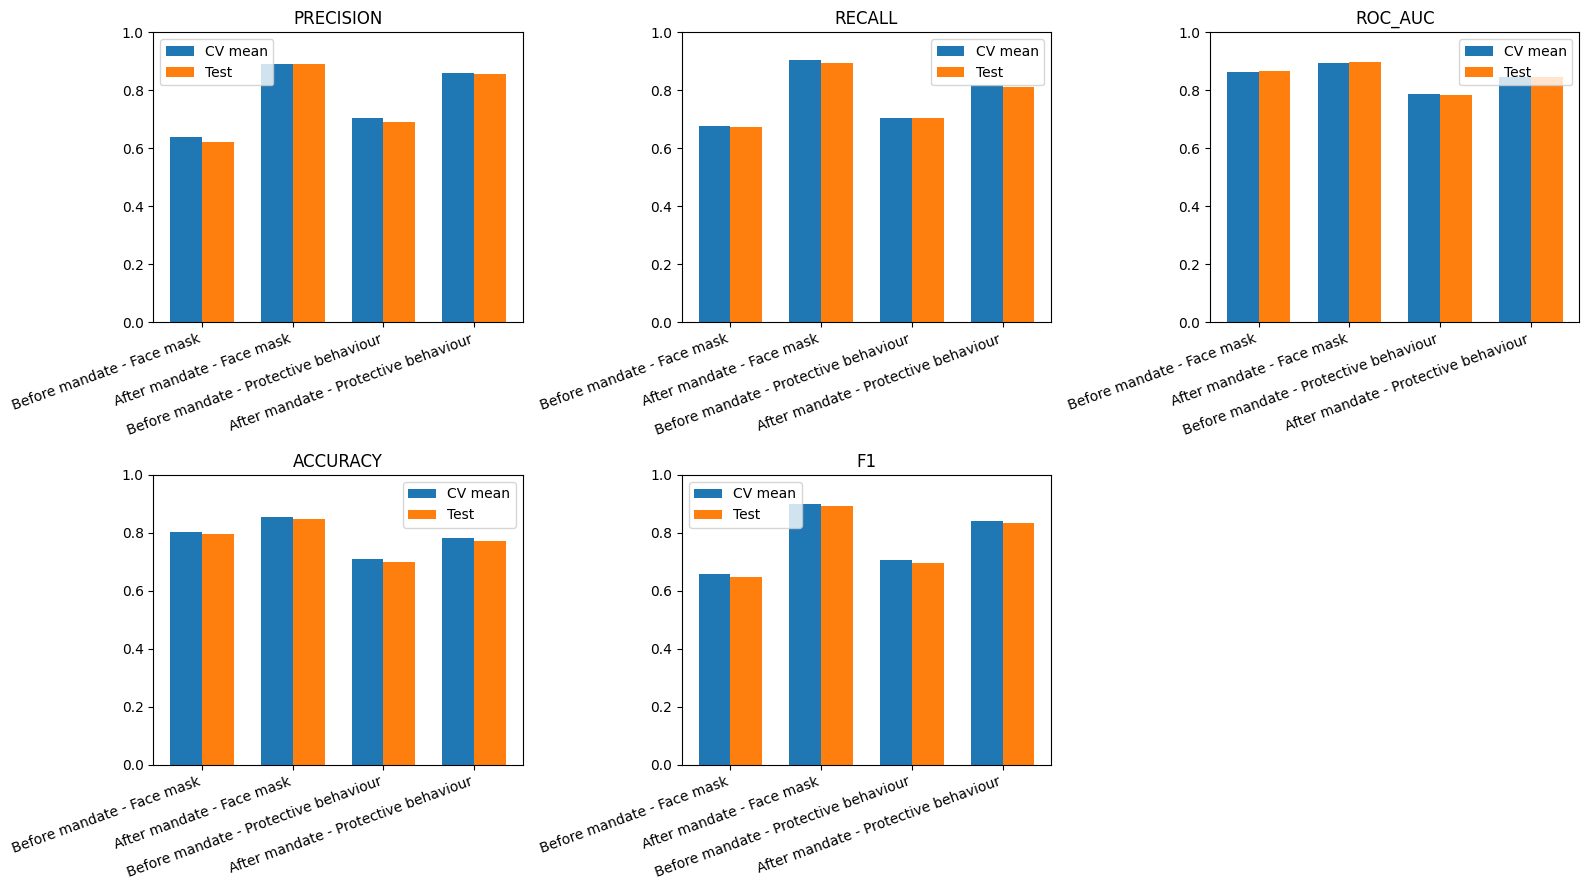

In [9]:
# Compare
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]

    cv_vals = cv_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    test_vals = test_summary_df.set_index("task").loc[list(TASKS.keys()), metric]

    x = np.arange(len(TASKS))
    width = 0.35

    ax.bar(x - width / 2, cv_vals.values, width=width, label="CV mean")
    ax.bar(x + width / 2, test_vals.values, width=width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(list(TASKS.values()), rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(metric.upper())
    ax.legend()




axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 4.6 ROC curve


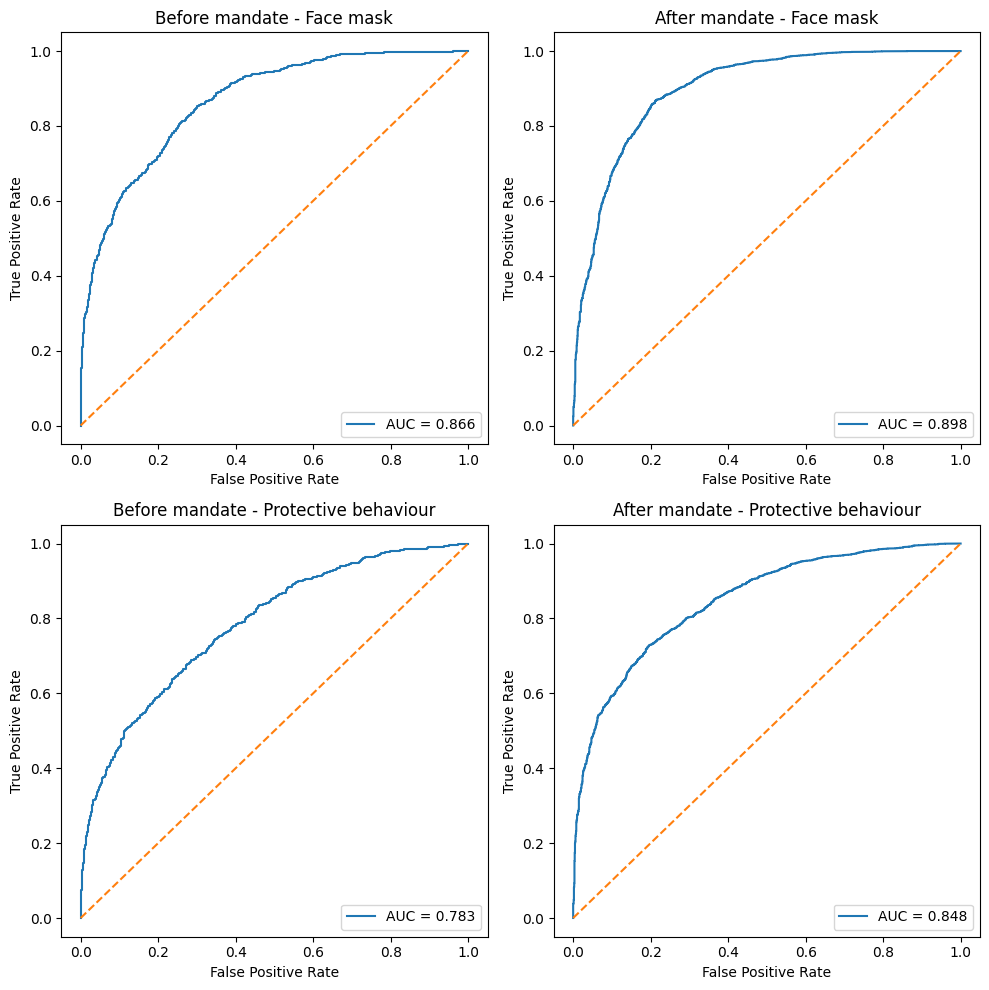

In [10]:
# Plot ROC curves
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    y_test = results[task]["y_test"]
    y_prob = results[task]["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")



plt.tight_layout()
plt.show()

### 4.7 Confusion matrix heatmap


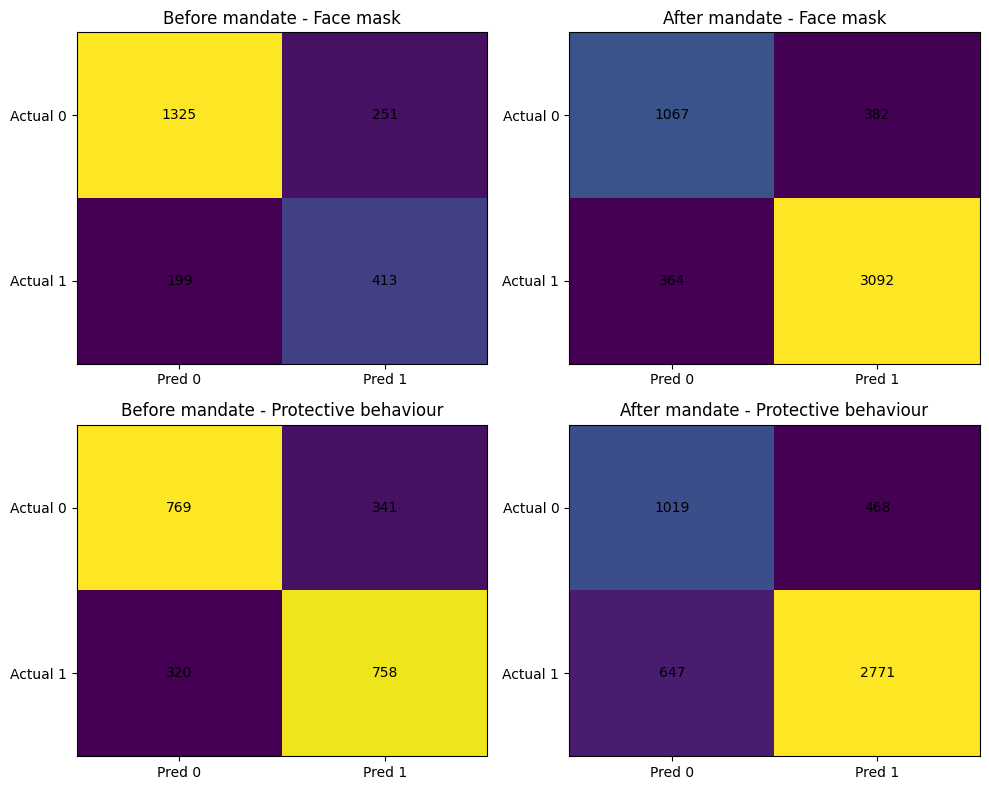

In [11]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    cm = results[task]["cm"]
    ax.imshow(cm, aspect="auto")
    ax.set_title(TASKS[task])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])


    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")





plt.tight_layout()
plt.show()

### 4.8 Top feature importance


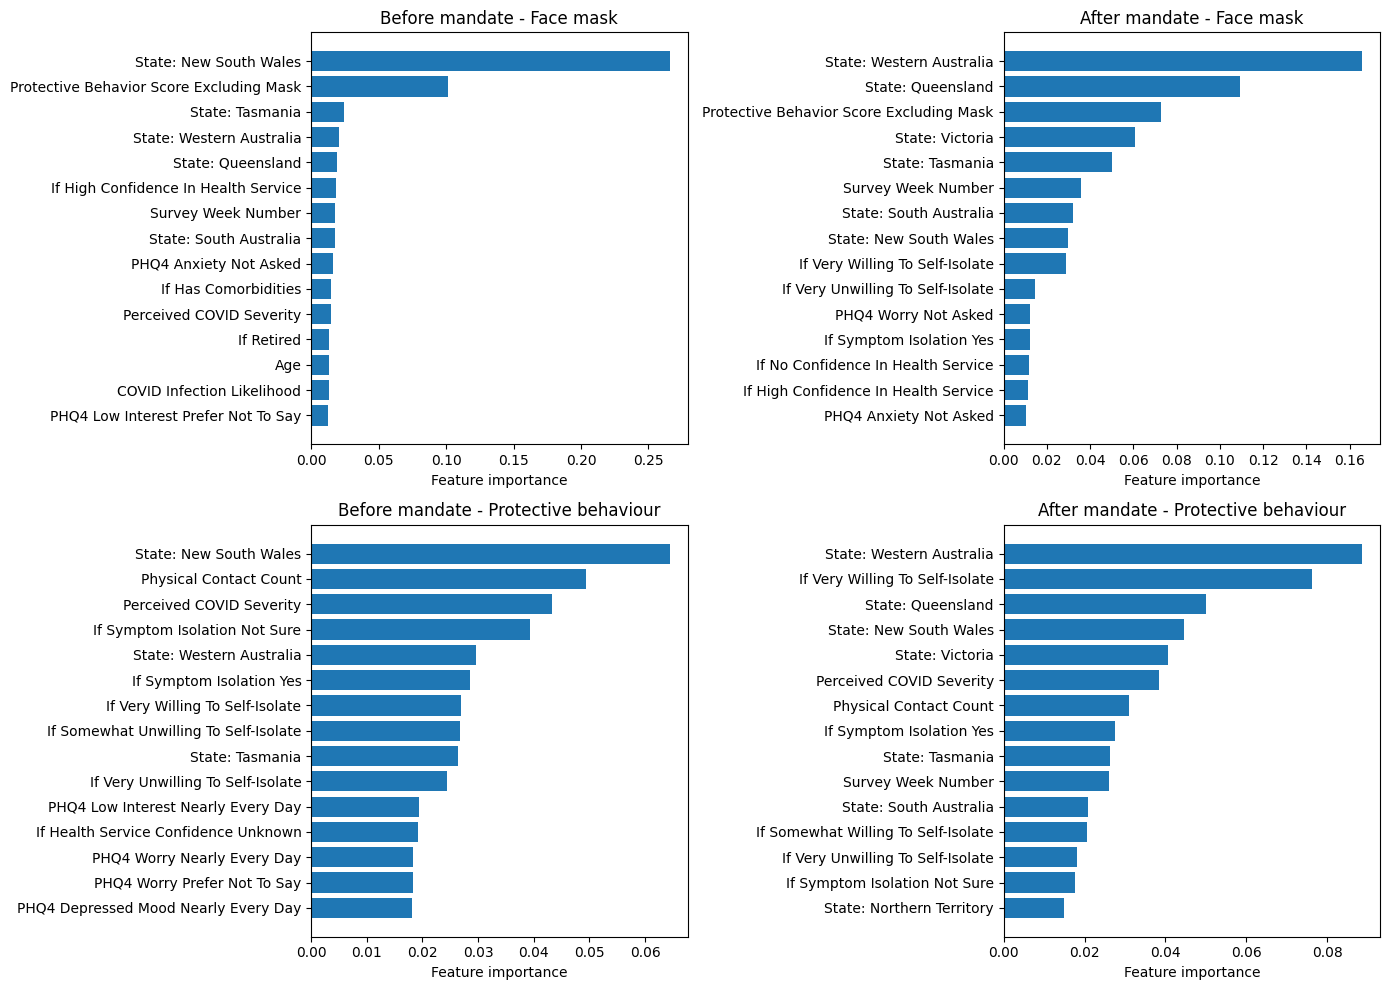

In [ ]:
# Plot the top feature importances
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASKS.keys()):
    importance_df = results[task]["importance_df"]
    top_df = importance_df.head(TOP_N_FEATURES).sort_values("importance", ascending=True)
    ax.barh(top_df["feature"], top_df["importance"])
    ax.set_title(TASKS[task])
    ax.set_xlabel("Feature importance")



plt.tight_layout()
plt.show()

### 4.9 All Model Indicators


In [13]:
# Main CV and test indicators
metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
metric_names = {"roc_auc": "AUC","f1": "F1","accuracy": "Accuracy","precision": "Precision","recall": "Recall",}


task_order = list(TASKS.keys())


cv_tbl = (cv_summary_df.set_index("task").loc[task_order, ["label"] + metric_order].copy())



test_tbl = (test_summary_df.set_index("task").loc[task_order, metric_order].copy())

summary_table = pd.DataFrame({"Task": cv_tbl["label"].values})

for metric in metric_order:
    summary_table[f"CV {metric_names[metric]}"] = cv_tbl[metric].round(3).values
    summary_table[f"Test {metric_names[metric]}"] = test_tbl[metric].round(3).values



display(summary_table)

,Task,CV AUC,Test AUC,CV F1,Test F1,CV Accuracy,Test Accuracy,CV Precision,Test Precision,CV Recall,Test Recall
0,Before mandate - Face mask,0.864,0.866,0.656,0.647,0.802,0.794,0.639,0.622,0.676,0.675
1,After mandate - Face mask,0.893,0.898,0.899,0.892,0.856,0.848,0.892,0.890,0.905,0.895
2,Before mandate - Protective behaviour,0.788,0.783,0.705,0.696,0.709,0.698,0.706,0.690,0.703,0.703
3,After mandate - Protective behaviour,0.844,0.848,0.840,0.833,0.782,0.773,0.861,0.856,0.820,0.811
